# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 138.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 174.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 133.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 167.2 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [27]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head(10)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


In [14]:
df[['ConvertedCompYearly']].head(10)

,ConvertedCompYearly
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [4]:
converted_yearly_new = df['ConvertedCompYearly'].dropna()

missing_val_converted = converted_yearly_new.isna().sum()
print(missing_val_converted)


0


In [16]:
df[['ConvertedCompYearly']].value_counts()

ConvertedCompYearly
64444.0                321
53703.0                308
75184.0                230
85925.0                226
107406.0               208
                      ... 
25489.0                  1
25532.0                  1
25563.0                  1
25597.0                  1
25661.0                  1
Name: count, Length: 6113, dtype: int64

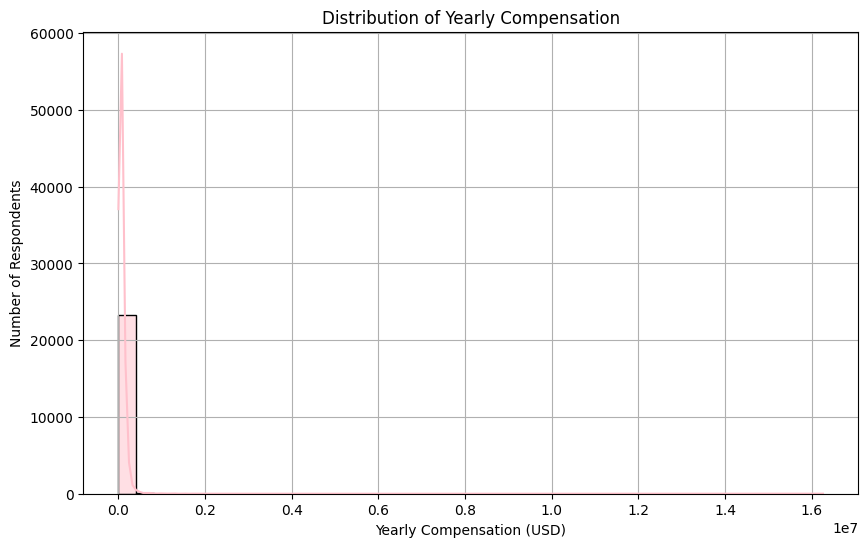

In [20]:
#Plot the distribution and histogram for ConvertedCompYearly
#before filtering 
# Plot distribution using Seaborn
plt.figure(figsize=(10,6))
sns.histplot(converted_yearly_new, bins=40, kde=True, color='pink')
plt.title('Distribution of Yearly Compensation')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.grid(True)
plt.show()


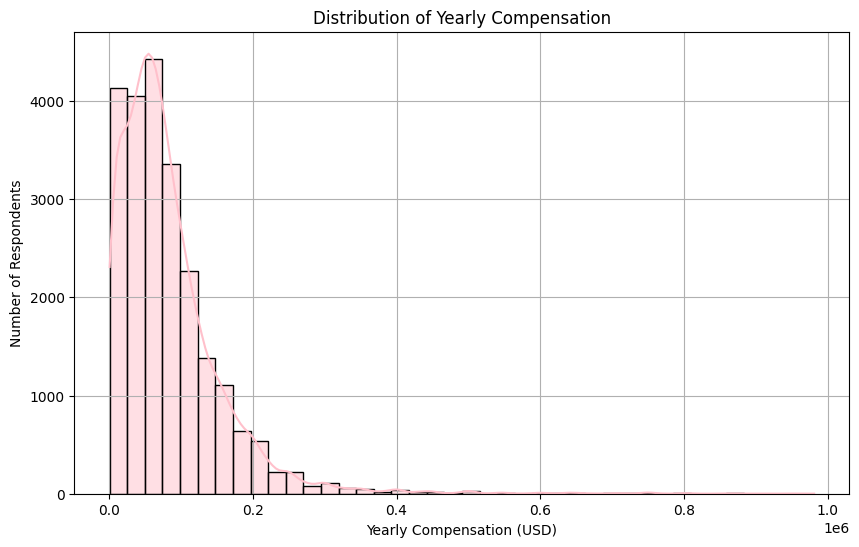

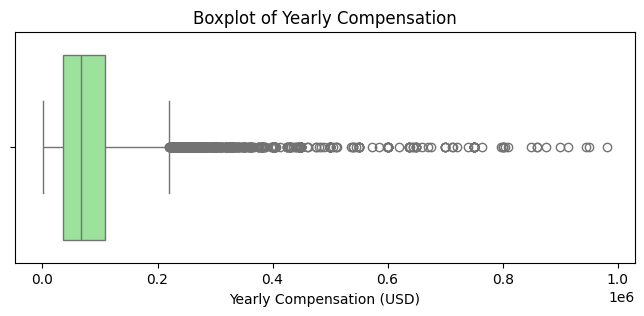

In [22]:
# Step 3: Analyze and Visualize Compensation Distribution
#after filtering 

# Optional but important to see the distribution: Filter unrealistic values (for example, below $1k or above $1M)
converted_yearly_new = converted_yearly_new[(converted_yearly_new > 1000) & (converted_yearly_new < 1_000_000)]

# Plot distribution using Seaborn
plt.figure(figsize=(10,6))
sns.histplot(converted_yearly_new, bins=40, kde=True, color='pink')
plt.title('Distribution of Yearly Compensation')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.grid(True)
plt.show()

# Optional: Boxplot to detect outliers
plt.figure(figsize=(8,3))
sns.boxplot(x=converted_yearly_new, color='lightgreen')
plt.title('Boxplot of Yearly Compensation')
plt.xlabel('Yearly Compensation (USD)')
plt.show()

#Baris tersebut menyaring (filter) data ConvertedCompYearly sehingga hanya menampilkan nilai gaji 
#tahunan antara $1.000 dan $1.000.000.

#Artinya:

#Nilai di bawah 1.000 USD (mungkin data salah input, seperti “0” atau “5”) akan dihapus.

#Nilai di atas 1.000.000 USD (misalnya CEO atau outlier ekstrem) juga dihapus, agar grafik lebih representatif.

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [46]:
# Filter hanya untuk responden yang bekerja full-time
full_time = df[df['Employment'] == 'Employed, full-time']

# Ambil kolom kompensasi dan hilangkan nilai kosong
full_time_comp = full_time['ConvertedCompYearly'].dropna()

# Hitung median
median_comp = full_time_comp.median()

print(f"Median Yearly Compensation for Full-Time Employees: ${median_comp:,.2f}")


Median Yearly Compensation for Full-Time Employees: $69,814.00


In [55]:
#another example : filter the data to calculate the minim compensation for respondents whose employment 
#status is "Student, full-time"

student_full_time = df[df['Employment'] == 'Student, full-time']
df_subset = df.dropna(subset=['ConvertedCompYearly'])

minim_comp = student_comp.max()
print(f"(Minim compensation for student, full-time : ${minim_comp:,.2f}")

(Minim compensation for student, full-time : $16,256,603.00


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


# Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



In [ ]:
CARA PERTAMA

In [56]:
Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1:,.2f}")
print(f"Q3: {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")

Q1: 32,712.00
Q3: 107,971.50
IQR: 75,259.50


In [57]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:,.2f}")
print(f"Upper Bound: {upper_bound:,.2f}")


Lower Bound: -80,177.25
Upper Bound: 220,860.75


In [67]:
# Select only relevant columns and drop missing values
country_comp = df[['Country', 'ConvertedCompYearly']].dropna()

outliers = df[(df["ConvertedCompYearly"] < lower_bound) | 
              (df["ConvertedCompYearly"] > upper_bound)]

print(f"Jumlah outlier: {len(outliers)}")


Jumlah outlier: 978


/tmp/ipykernel_351/1059424106.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


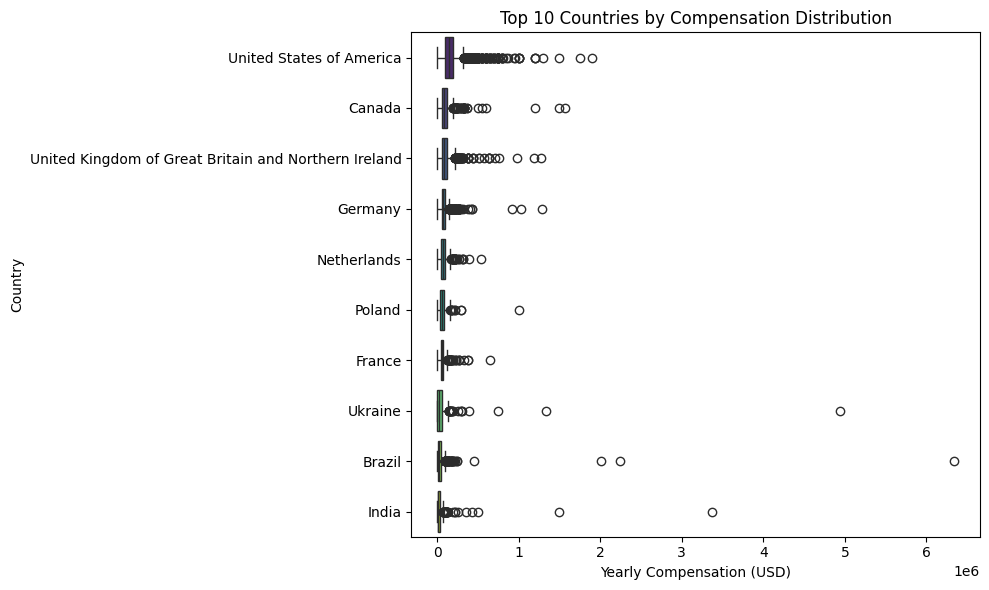

In [75]:
# Filter top 10 countries by number of respondents


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
top_countries = (
    country_comp['Country']
    .value_counts()
    .head(10)
    .index
)

filtered = country_comp[country_comp['Country'].isin(top_countries)]

plt.figure(figsize=(10,6))
sns.boxplot(
    data=filtered,
    x='ConvertedCompYearly',
    y='Country',
    order=filtered.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=False).index,
    palette='viridis',
    color='pink'
)
plt.title('Top 10 Countries by Compensation Distribution')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


In [ ]:
CARA KEDUA

/tmp/ipykernel_351/17487452.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


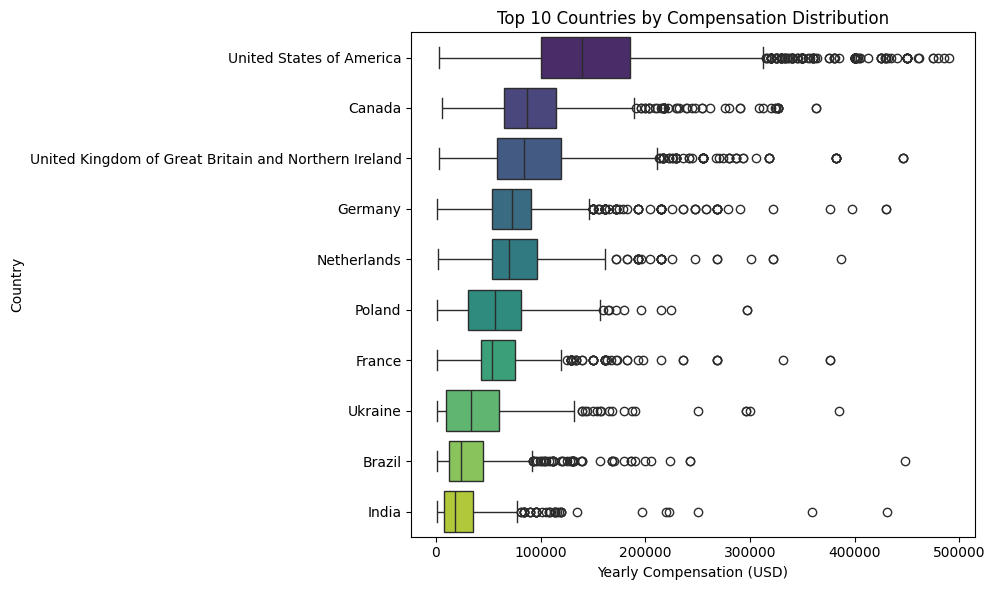

In [65]:
# Step 5: Analyze Compensation Range and Distribution by Country

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only relevant columns and drop missing values
country_comp = df[['Country', 'ConvertedCompYearly']].dropna()

# Optional: Filter unrealistic or extreme values for better visualization
country_comp = country_comp[
    (country_comp['ConvertedCompYearly'] > 1000) &
    (country_comp['ConvertedCompYearly'] < 500000)
]

# Filter top 10 countries by number of respondents
top_countries = (
    country_comp['Country']
    .value_counts()
    .head(10)
    .index
)

filtered = country_comp[country_comp['Country'].isin(top_countries)]

plt.figure(figsize=(10,6))
sns.boxplot(
    data=filtered,
    x='ConvertedCompYearly',
    y='Country',
    order=filtered.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=False).index,
    palette='viridis'
)
plt.title('Top 10 Countries by Compensation Distribution')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()



<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [76]:
#Buat DataFrame baru tanpa outlier

#Gunakan filtering condition untuk menyaring hanya data dalam batas normal. Yaitu kurang dari 
#lower_bound dan tidak lebih besar dari upper_bound

df_no_outliers = df[
    (df["ConvertedCompYearly"] >= lower_bound) &
    (df["ConvertedCompYearly"] <= upper_bound)
].copy()


#✅ Penjelasan:

#>= lower_bound → hanya ambil data di atas batas bawah

#<= upper_bound → hanya ambil data di bawah batas atas

#.copy() → membuat salinan baru agar tidak mengubah DataFrame asli

In [77]:
#Validasi ukuran DataFrame baru

#Bandingkan jumlah baris sebelum dan sesudah penghapusan outlier.

print(f"Jumlah data asli: {len(df)}")
print(f"Jumlah data setelah menghapus outlier: {len(df_no_outliers)}")
print(f"Data yang dihapus (outlier): {len(df) - len(df_no_outliers)}")


# Interpretasi:

#Kalau dataset awal punya 60.000 baris, dan setelah pembersihan tinggal 57.000 → 
#berarti sekitar 3.000 data (5%) terdeteksi sebagai outlier.

Jumlah data asli: 65437
Jumlah data setelah menghapus outlier: 22457
Data yang dihapus (outlier): 42980


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [81]:
df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].head()

,ConvertedCompYearly,WorkExp,JobSatPoints_1
0,NaN,NaN,NaN
1,NaN,17.0,0.0
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


In [83]:
drop_missing_value = df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].dropna()
#df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].isna().sum()
# jika pakai code ini maka yang diambil adalah DF asli bukan yang sudah dibersihkan 

#mengambil data yang sudah dibersikan NaN
drop_missing_value.isna().sum()

ConvertedCompYearly    0
WorkExp                0
JobSatPoints_1         0
dtype: int64

In [85]:
#pengecekan apakah ada tipe data yang object atau buka numeric 
df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].dtypes

ConvertedCompYearly    float64
WorkExp                float64
JobSatPoints_1         float64
dtype: object

In [91]:
drop_missing_value.corr()

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.153182,0.020156
WorkExp,0.153182,1.000000,-0.028839
JobSatPoints_1,0.020156,-0.028839,1.000000


In [96]:
corr_matrix = drop_missing_value.corr()
print(corr_matrix)

                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.153182        0.020156
WorkExp                         0.153182  1.000000       -0.028839
JobSatPoints_1                  0.020156 -0.028839        1.000000


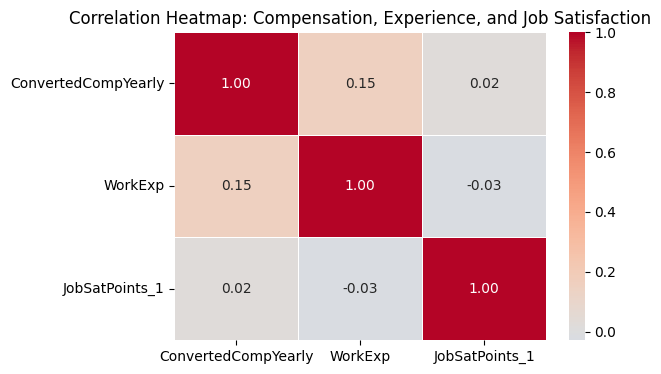

In [97]:
# Visualisasi menggunakan heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,        # tampilkan nilai korelasi
    cmap='coolwarm',   # skema warna (biru = negatif, merah = positif)
    center=0,
    fmt=".2f",         # format angka dua desimal
    linewidths=0.5
)
plt.title('Correlation Heatmap: Compensation, Experience, and Job Satisfaction')
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


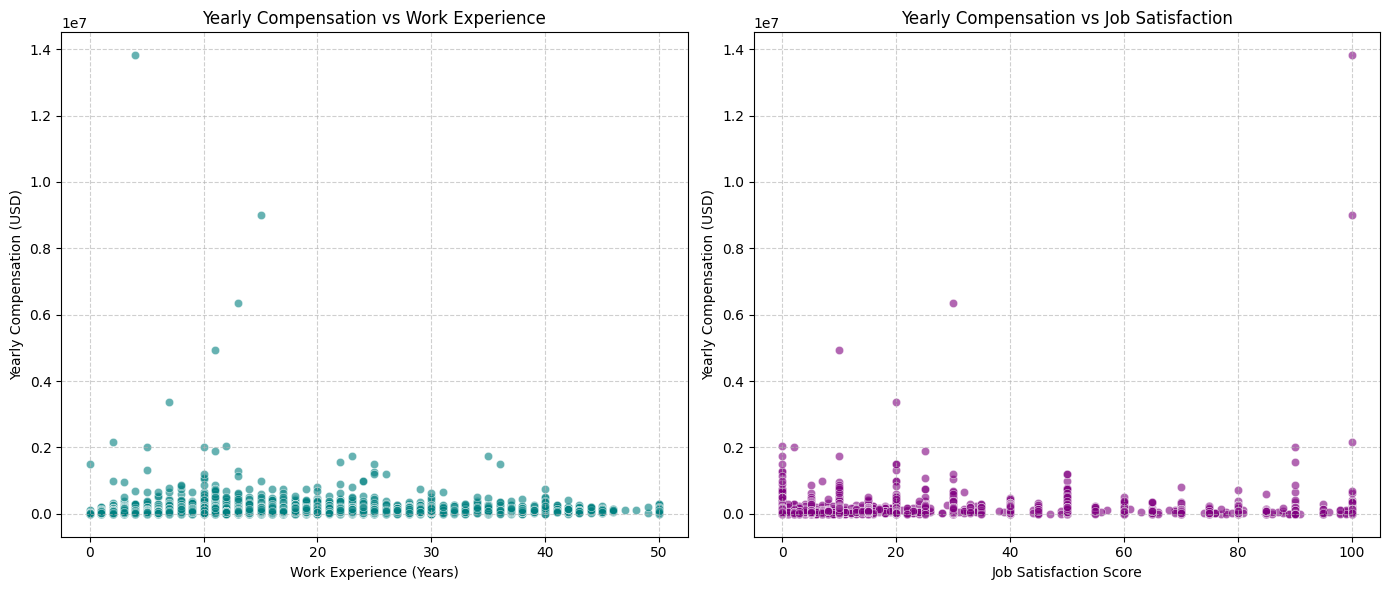

In [93]:
# Step 6: Create scatter plots to examine specific correlations

import matplotlib.pyplot as plt
import seaborn as sns

# Buat figure dengan dua scatter plot berdampingan
plt.figure(figsize=(14, 6))

# Plot 1: Gaji vs Pengalaman Kerja
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df,
    x='WorkExp',
    y='ConvertedCompYearly',
    alpha=0.6,         # transparansi supaya titik tidak terlalu padat
    color='teal'
)
plt.title('Yearly Compensation vs Work Experience')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Yearly Compensation (USD)')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Gaji vs Kepuasan Kerja
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x='JobSatPoints_1',
    y='ConvertedCompYearly',
    alpha=0.6,
    color='purple'
)
plt.title('Yearly Compensation vs Job Satisfaction')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Yearly Compensation (USD)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.
